In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predit the next one?
X, Y = [], [] # X is input to NN, Y are the labels for each example in X
for w in words:
    
    # print(w)
    context = [0] * block_size
    
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predit the next one?
    X, Y = [], [] # X is input to NN, Y are the labels for each example in X
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
C = torch.randn((27, 2))

In [9]:
# X is a 32 x 3 matrix, and for each, we are fetching a 2 dimensional embedding,
# so, 32 x 3 x 2 = 96 x 2
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [10]:
W1 = torch.randn((6, 100)) # 3 inputs x 2 dimensions = 6, and 100 neurons (hyperparameter - up to us to decide)
b1 = torch.randn(100)

In [11]:
# Y = x * weight + bias
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [12]:
h

tensor([[-0.9435,  0.6002,  0.5574,  ..., -0.8964,  0.9535,  0.4681],
        [-0.8223,  0.9464,  0.9454,  ..., -0.9969,  0.9921,  0.5892],
        [-0.6665, -0.8827, -0.7199,  ..., -0.9162,  0.9168,  0.9270],
        ...,
        [-0.9913,  0.8920,  0.9951,  ..., -0.9999,  0.9873, -0.1957],
        [-0.8414, -0.9324, -0.3620,  ..., -0.9280,  0.5425,  0.0334],
        [-0.9927,  0.9099, -0.9993,  ...,  0.8110,  1.0000, -0.6331]])

In [13]:
h.shape

torch.Size([228146, 100])

In [14]:
W2 = torch.randn((100, 27)) # 100 inputs, and 27 neurons (27 possible characters that come next)
b2 = torch.randn(27)

In [15]:
logits = h @ W2 + b2

In [16]:
logits.shape

torch.Size([228146, 27])

In [17]:
counts = logits.exp()

In [18]:
prob = counts / counts.sum(1, keepdims=True)

In [19]:
prob.shape

torch.Size([228146, 27])

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean() # negative log-likelihood loss function
loss

In [21]:
# ------------------- REORG ------------------

In [23]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predit the next one?

def build_dataset(words):
    X, Y = [], [] # X is input to NN, Y are the labels for each example in X
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [24]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182437, 3]), torch.Size([182437]))

In [196]:
# Vocabulary (fixed by the dataset — NOT tunable)
vocab_size = 27 # 27 possible chars: 26 letters + '.'

# Hyperparameters (can tune these)
embedding_dim = 20       # each char -> a 10-dim learned vector
hidden_layer_size = 200  # number of neurons in the hidden layer

# Derived (computed from the above)
input_size = block_size * embedding_dim   # flattened context: 3 × 10 = 30

# Reproducibility: fixed seed so runs are comparable when tuning
g = torch.Generator().manual_seed(2147483647)

# Parameters (weight matrix is (in_features, out_features); bias matches out)
C  = torch.randn((vocab_size, embedding_dim), generator=g)
#                  in: 27 rows (one per char)   out: 10-dim embedding each

W1 = torch.randn((input_size, hidden_layer_size), generator=g) * ((5/3)/(input_size**0.5))
#                  in: 30 (flattened context)    out: 200 (hidden neurons)
# b1 = torch.randn(hidden_layer_size, generator=g) * 0.01
#                 200 - one bias per hidden neuron

W2 = torch.randn((hidden_layer_size, vocab_size), generator=g) * 0.01
#                  in: 200 (hidden out)           out: 27 (one score per next char)
b2 = torch.randn(vocab_size, generator=g) * 0
#                 27 - one bias per output class

# BatchNorm parameters
bngain = torch.ones((1, hidden_layer_size))
bnbias = torch.zeros((1, hidden_layer_size))
bnmean_running = torch.zeros((1, hidden_layer_size))
bnstd_running = torch.ones((1, hidden_layer_size))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

18367


In [197]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the cahracters into vectors; 32 x 3 x 2 = 96 x 2
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # linear layer
    hpreact = emb.view(-1, input_size) @ W1 # + b1 # hidden layer pre-activation
    # batchnorm layer
    # ---------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * ((hpreact - bnmeani) / (bnstdi)) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # ---------------------------------------------------------------
    # non-linearity layer
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # helps with efficiency and better ops
    # print(loss.item())
     
    # backward pass
    for p in parameters: # reset
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 10**-0.8 if i < 100000 else 0.01 # based on graph: min loss at lre = -0.8, so ~0.158
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lossi.append(loss.log10().item())
    
    # break

print(loss.item())

2.021441698074341


In [198]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * ((hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True))) + bnbias
    hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running)) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0491650104522705
val 2.113429069519043


In [158]:
emb = C[Xtr] # 32 x 3 x 2 = 96 x 2
h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) # helps with efficiency and better ops
loss.item()

2.0041215419769287

In [159]:
emb = C[Xdev] # 32 x 3 x 2 = 96 x 2
h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # helps with efficiency and better ops
loss.item()

2.097878932952881

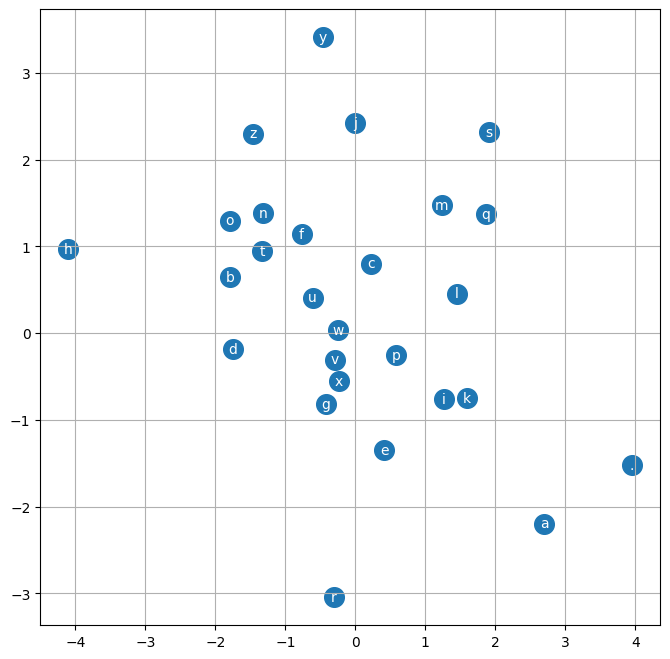

In [40]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [41]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [42]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: break

    print(''.join(itos[i] for i in out))

carmah.
ambril.
khi.
milia.
atlanna.
sane.
rah.
bradhviyat.
kaeli.
nellara.
chaily.
kaleigh.
ham.
joce.
quinthorline.
livabi.
wazelo.
dearyn.
kai.
eveigh.


In [59]:
# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
# logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([0., 0., 0., 0.]),
 tensor([0.2500, 0.2500, 0.2500, 0.2500]),
 tensor(1.3863))

In [199]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [200]:
# --------------- SUMMARY -------------------

In [279]:
# Training a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calc the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)              # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit var
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

n_embd = 20 # the dim of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 5
    # layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of params in total
for p in parameters:
    p.requires_grad = True
                   

181021


In [280]:
# same optimization as prev
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the cahracters into vectors; 32 x 3 x 2 = 96 x 2
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
     
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters: # reset
        p.grad = None
    loss.backward()
    
    # update
    lr = 10**-0.8 if i < 100000 else 0.01 # based on graph: min loss at lre = -0.8, so ~0.158
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break

      0/ 200000: 11.0322


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 2.80%
layer 5 (      Tanh): mean +0.00, std 0.65, saturated: 2.08%
layer 8 (      Tanh): mean +0.00, std 0.65, saturated: 1.66%
layer 11 (      Tanh): mean -0.00, std 0.66, saturated: 1.20%
layer 14 (      Tanh): mean +0.00, std 0.67, saturated: 0.50%


Text(0.5, 1.0, 'activation distribution')

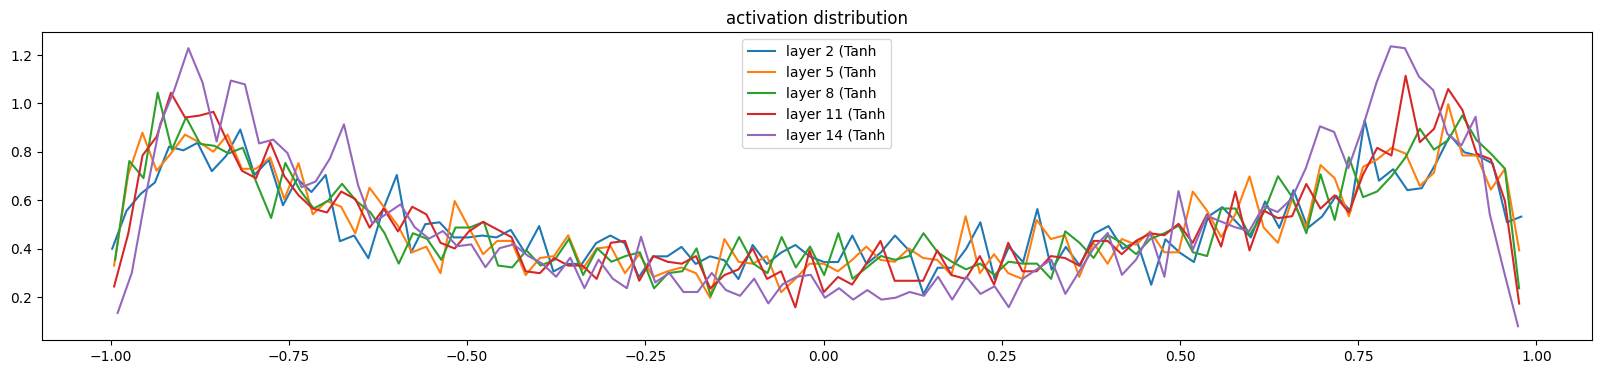

In [281]:
# visualize histograms
plt.figure(figsize=(20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 1.531411e-03
layer 5 (      Tanh): mean -0.000000, std 1.321769e-03
layer 8 (      Tanh): mean -0.000000, std 1.351996e-03
layer 11 (      Tanh): mean -0.000000, std 1.482451e-03
layer 14 (      Tanh): mean -0.000000, std 2.174741e-03


Text(0.5, 1.0, 'gradient distribution')

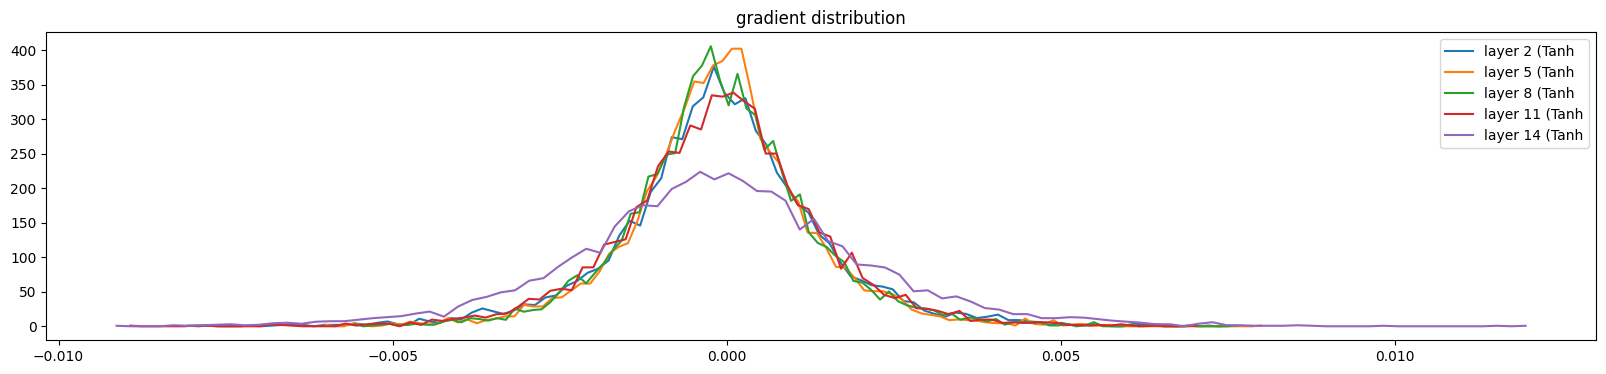

In [282]:
# visualize histograms
plt.figure(figsize=(20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 20) | mean -0.000000 | std 5.425961e-03 | grad:data ratio 5.490494e-03
weight  (60, 200) | mean -0.000027 | std 3.473477e-03 | grad:data ratio 1.588647e-02
weight (200, 200) | mean +0.000020 | std 2.512941e-03 | grad:data ratio 2.096572e-02
weight (200, 200) | mean +0.000016 | std 2.169316e-03 | grad:data ratio 1.811979e-02
weight (200, 200) | mean +0.000005 | std 2.122588e-03 | grad:data ratio 1.777984e-02
weight (200, 200) | mean +0.000000 | std 2.306541e-03 | grad:data ratio 1.935243e-02
weight  (200, 27) | mean +0.000020 | std 7.524025e-03 | grad:data ratio 5.652826e-02


Text(0.5, 1.0, 'weights gradient distribution')

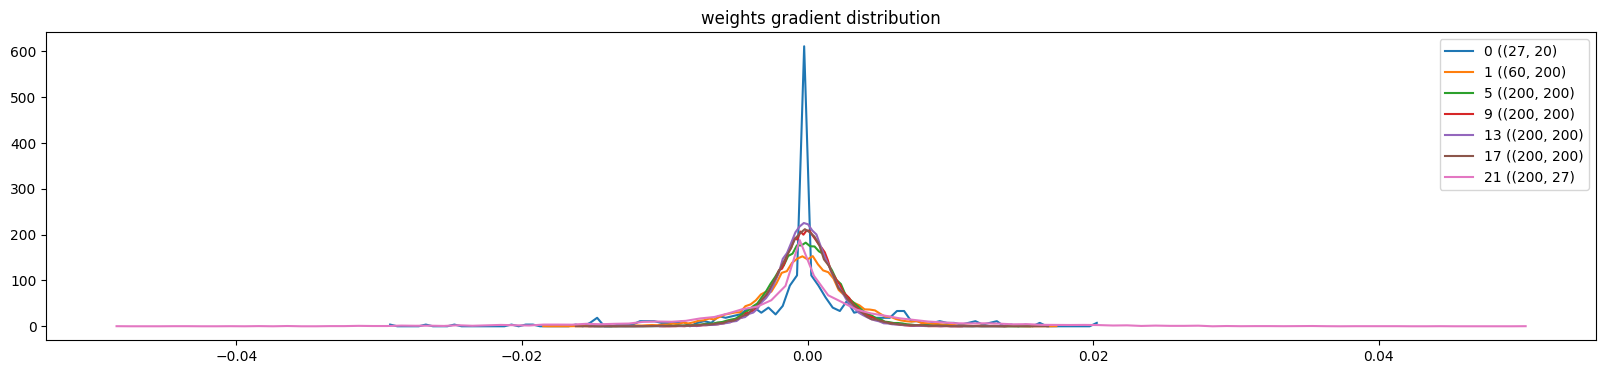

In [283]:
# visualize histograms
plt.figure(figsize=(20,4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} ({tuple(p.shape)}')
plt.legend(legends);
plt.title('weights gradient distribution')

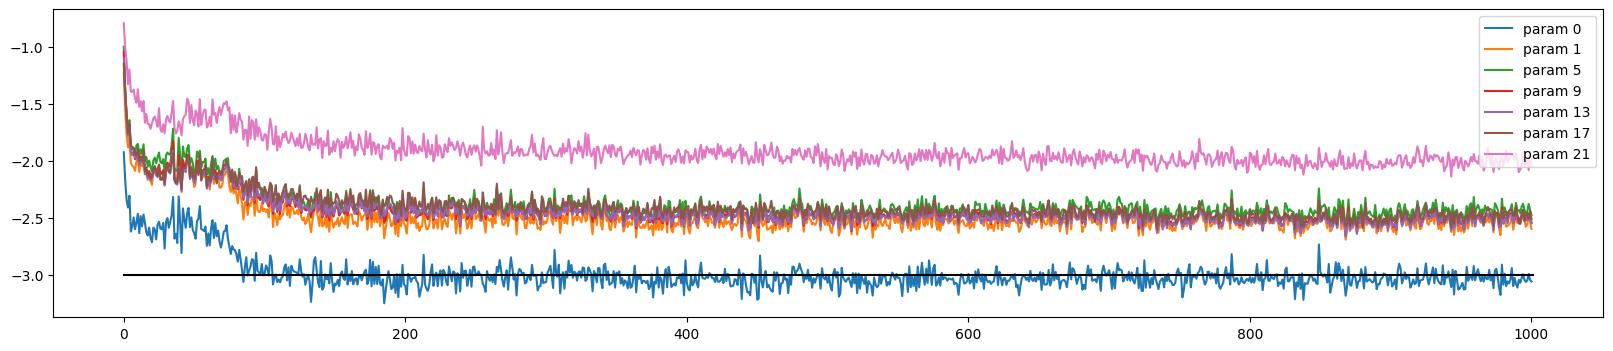

In [284]:
# visualize histograms
plt.figure(figsize=(20,4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);